# Task 3: Car Price Prediction with Machine Learning
## Objective
Build a regression model that predicts the selling price of a used car based on features such as brand, age, mileage, fuel type, and transmission

## Step 0: Download Dataset and Import Libraries
We will use the widely used Vehicle Dataset from CarDekho.

### 0.1. Import the required libraries

In [49]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

### 0.2 Load the dataset

In [50]:
df = pd.read_csv("/kaggle/input/datasets/sukhmandeepsinghbrar/car-price-prediction-dataset/cardekho.csv")

#Verify
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


### 0.3. Inspect the complete dataset information

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   object 
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   object 
 5   seller_type         8128 non-null   object 
 6   transmission        8128 non-null   object 
 7   owner               8128 non-null   object 
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   object 
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 762.1+ KB


## Step1: Data Cleaning
### 1.1. Check Missing Values

In [52]:
df.isnull().sum()

name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)    221
engine                221
max_power             215
seats                 221
dtype: int64

### 1.2. Check Duplicate Rows

In [53]:
df.duplicated().sum()

np.int64(1202)

In [54]:
#Remove duplicate rows
df = df.drop_duplicates()

#Verify
df.duplicated().sum()

np.int64(0)

### 1.3. Adress Inconsistent Categorical Values

In [55]:
#The categorical columns in our dataset are:
categorical_columns = [
    "fuel",
    "seller_type",
    "transmission",
    "owner"
]

In [56]:
#We inspect their unique values
for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())


fuel:
['Diesel' 'Petrol' 'LPG' 'CNG']

seller_type:
['Individual' 'Dealer' 'Trustmark Dealer']

transmission:
['Manual' 'Automatic']

owner:
['First Owner' 'Second Owner' 'Third Owner' 'Fourth & Above Owner'
 'Test Drive Car']


### Categorical Value Consistency

The categorical features were inspected for inconsistent labels. The values in the `fuel`, `seller_type`, `transmission`, and `owner` columns were found to be consistently formatted, with no apparent duplicate categories caused by differences in capitalization or whitespace. Therefore, no categorical standardization was required.

## Step 2: Feature Engineering

Feature engineering is creating useful variables from the existing raw data to make the dataset more informative for analysis and machine learning.

In this step, we will create:

+ **car_age** from year
+ **brand** from name

### 2.1. Calculate Car Age

In [57]:
#For reproducibility, we explicitly define the reference year:
REFERENCE_YEAR = 2026

In [58]:
#create the new feature
df["car_age"] = REFERENCE_YEAR - df["year"]

#Verify
df[["year", "car_age"]].head()

,year,car_age
0,2014,12
1,2014,12
2,2006,20
3,2010,16
4,2007,19


### 2.2. Extract the Car Brand

In [59]:
#Extract brand from name
df["brand"] = (
    df["name"]
    .str.split()
    .str[0]
)

#Verify
df[["name", "brand"]].head(40)

,name,brand
0,Maruti Swift Dzire VDI,Maruti
1,Skoda Rapid 1.5 TDI Ambition,Skoda
2,Honda City 2017-2020 EXi,Honda
3,Hyundai i20 Sportz Diesel,Hyundai
4,Maruti Swift VXI BSIII,Maruti
5,Hyundai Xcent 1.2 VTVT E Plus,Hyundai
6,Maruti Wagon R LXI DUO BSIII,Maruti
7,Maruti 800 DX BSII,Maruti
8,Toyota Etios VXD,Toyota
9,Ford Figo Diesel Celebration Edition,Ford


## Step 3: Exploratory Data Analysis (EDA)
The objective of EDA is to understand the data before training machine-learning models.

### 3.1. Distribution of Selling Prices

In [60]:
#Inspect our main variable basic statistics
df["selling_price"].describe()

count    6.926000e+03
mean     5.172707e+05
std      5.197670e+05
min      2.999900e+04
25%      2.500000e+05
50%      4.000000e+05
75%      6.335000e+05
max      1.000000e+07
Name: selling_price, dtype: float64

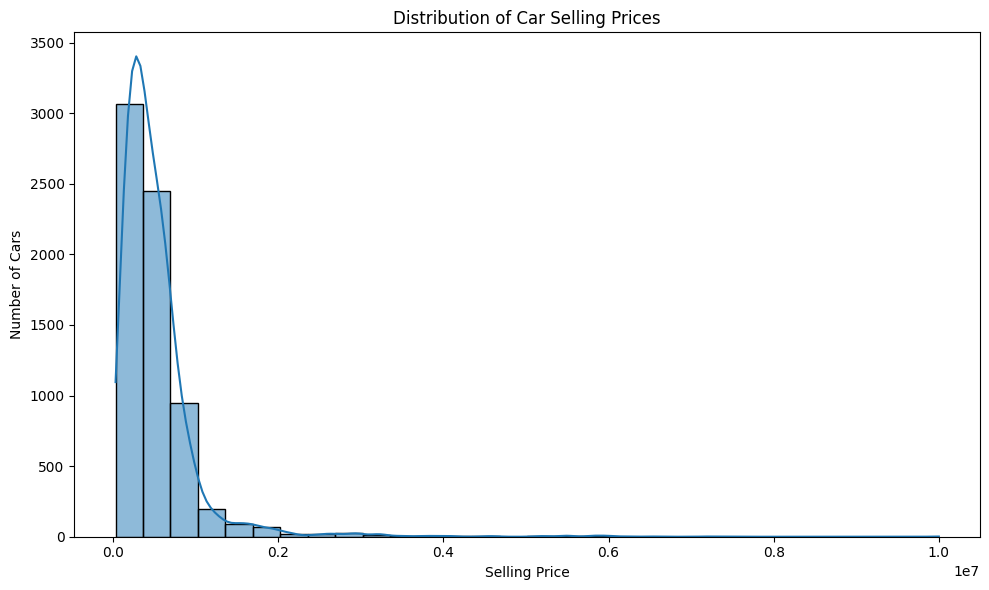

In [61]:
#Vizualization

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="selling_price",
    bins=30,
    kde=True
)

plt.title("Distribution of Car Selling Prices")

plt.xlabel("Selling Price")

plt.ylabel("Number of Cars")

plt.tight_layout()

plt.show()

### Observation

The distribution of selling prices is concentrated within the lower price range and shows a right-skewed pattern, with a smaller number of vehicles having substantially higher selling prices.

### 3.2. Selling Price vs. Fuel Type
We now investigate whether selling prices differ according to fuel type.

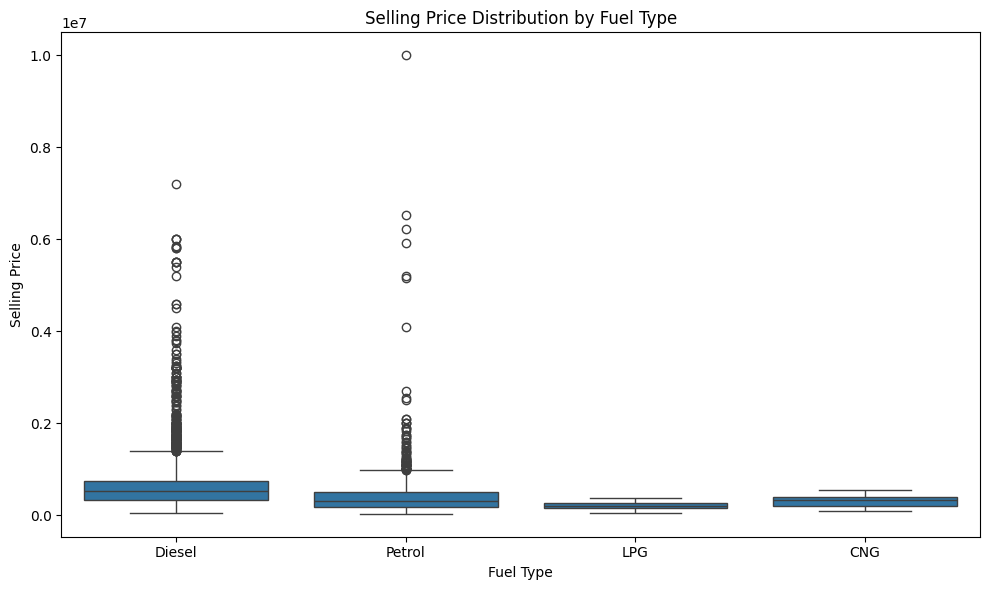

In [62]:
#Create the box plot
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="fuel",
    y="selling_price"
)

plt.title("Selling Price Distribution by Fuel Type")

plt.xlabel("Fuel Type")

plt.ylabel("Selling Price")

plt.tight_layout()

plt.show()

### Observation

The box plot shows differences in the distribution of selling prices across fuel types. Diesel vehicles have the highest median selling price and greatest price variability, while petrol shows the most extreme outliers, whereas LPG and CNG have lower, more consistent selling prices.

### 3.3. Selling Price vs. Car Age

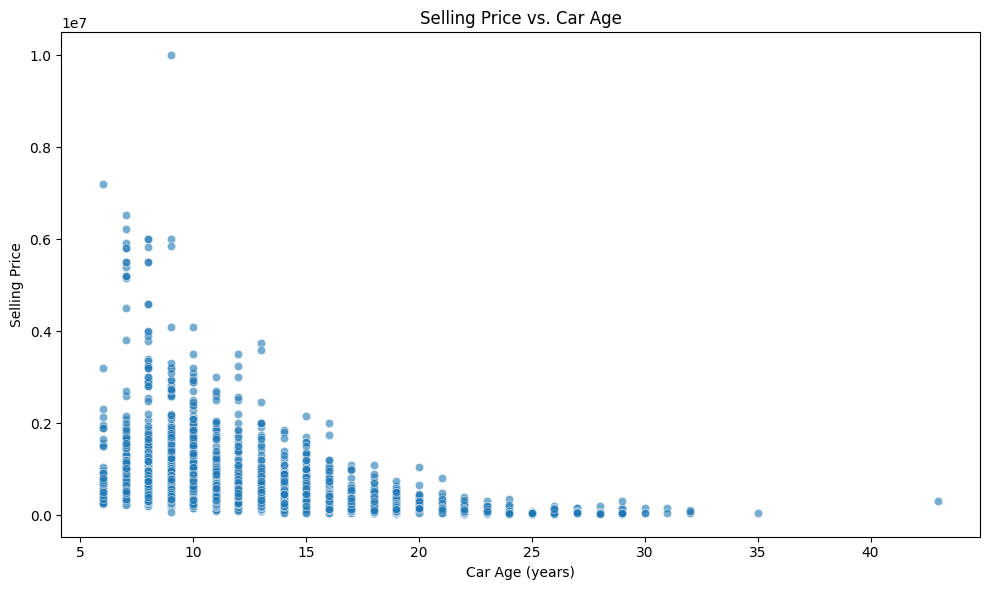

In [63]:
#We investigate the relationship between Selling price and car age
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="car_age",
    y="selling_price",
    alpha=0.6
)

plt.title("Selling Price vs. Car Age")

plt.xlabel("Car Age (years)")

plt.ylabel("Selling Price")

plt.tight_layout()

plt.show()

### Observation
The scatter plot shows a negative relationship between car age and selling price, indicating that older cars generally have lower selling prices, although a few high-priced outliers exist among relatively newer vehicles.

## Step 4: Encode Categorical Variables
Machine-learning models generally require numerical input. Our dataset contains categorical variables represented as text, and we need to transform these categories into numerical features using **One-Hot Encoding**

### 4.1. Select the categorical columns

In [64]:
categorical_columns = [
    "fuel",
    "seller_type",
    "transmission",
    "owner",
    "brand"
]

#verify that all these columns exist:
df[categorical_columns].head()

,fuel,seller_type,transmission,owner,brand
0,Diesel,Individual,Manual,First Owner,Maruti
1,Diesel,Individual,Manual,Second Owner,Skoda
2,Petrol,Individual,Manual,Third Owner,Honda
3,Diesel,Individual,Manual,First Owner,Hyundai
4,Petrol,Individual,Manual,First Owner,Maruti


### 4.2 Apply One-Hot Encoding

In [65]:
df_encoded = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

#Verify the result
df_encoded.columns.tolist()

['name',
 'year',
 'selling_price',
 'km_driven',
 'mileage(km/ltr/kg)',
 'engine',
 'max_power',
 'seats',
 'car_age',
 'fuel_Diesel',
 'fuel_LPG',
 'fuel_Petrol',
 'seller_type_Individual',
 'seller_type_Trustmark Dealer',
 'transmission_Manual',
 'owner_Fourth & Above Owner',
 'owner_Second Owner',
 'owner_Test Drive Car',
 'owner_Third Owner',
 'brand_Ashok',
 'brand_Audi',
 'brand_BMW',
 'brand_Chevrolet',
 'brand_Daewoo',
 'brand_Datsun',
 'brand_Fiat',
 'brand_Force',
 'brand_Ford',
 'brand_Honda',
 'brand_Hyundai',
 'brand_Isuzu',
 'brand_Jaguar',
 'brand_Jeep',
 'brand_Kia',
 'brand_Land',
 'brand_Lexus',
 'brand_MG',
 'brand_Mahindra',
 'brand_Maruti',
 'brand_Mercedes-Benz',
 'brand_Mitsubishi',
 'brand_Nissan',
 'brand_Opel',
 'brand_Peugeot',
 'brand_Renault',
 'brand_Skoda',
 'brand_Tata',
 'brand_Toyota',
 'brand_Volkswagen',
 'brand_Volvo']

In [66]:
#Check the new shape
df_encoded.shape

(6926, 50)

In [67]:
#Inspect the first rows
df_encoded.head()

,name,year,selling_price,km_driven,mileage(km/ltr/kg),engine,max_power,seats,car_age,fuel_Diesel,...,brand_Mitsubishi,brand_Nissan,brand_Opel,brand_Peugeot,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo
0,Maruti Swift Dzire VDI,2014,450000,145500,23.40,1248.0,74,5.0,12,True,...,False,False,False,False,False,False,False,False,False,False
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,21.14,1498.0,103.52,5.0,12,True,...,False,False,False,False,False,True,False,False,False,False
2,Honda City 2017-2020 EXi,2006,158000,140000,17.70,1497.0,78,5.0,20,False,...,False,False,False,False,False,False,False,False,False,False
3,Hyundai i20 Sportz Diesel,2010,225000,127000,23.00,1396.0,90,5.0,16,True,...,False,False,False,False,False,False,False,False,False,False
4,Maruti Swift VXI BSIII,2007,130000,120000,16.10,1298.0,88.2,5.0,19,False,...,False,False,False,False,False,False,False,False,False,False


## Step 5: Feature Correlation Heatmap

### 5.1. Verifying data

In [95]:
#Check data types
df.dtypes

name                   object
year                    int64
selling_price           int64
km_driven               int64
fuel                   object
seller_type            object
transmission           object
owner                  object
mileage(km/ltr/kg)    float64
engine                float64
max_power              object
seats                 float64
car_age                 int64
brand                  object
dtype: object

### 5.2. Remove non-numerical and redundant columns

The original name and year columns should be removed before model training because brand and car_age already capture the relevant information, making the original columns redundant and preventing unnecessary model complexity.

max_power is stored as text (object), although it contains numerical values.

In [96]:
df_model = df_encoded.drop(
    columns=["name", "year"]
)

In [97]:
df["max_power"].dtype

dtype('O')

In [98]:
#Type Conversion
df_model["max_power"] = pd.to_numeric(
    df_model["max_power"],
    errors="coerce"
)

In [100]:
#fill missing numerical values
numerical_columns = [
    "mileage(km/ltr/kg)",
    "engine",
    "max_power",
    "seats"
]

for column in numerical_columns:
    df_model[column] = df_model[column].fillna(
        df_model[column].median()
    )

In [101]:
#Verify that no missing values remain
df_model.isnull().sum().sum()

np.int64(0)

### 5.3. Calculating the Correlation Matrix

In [102]:
#Calculate the correlation matrix
correlation_matrix = df_model.corr()

### 5.4. Displaying Results

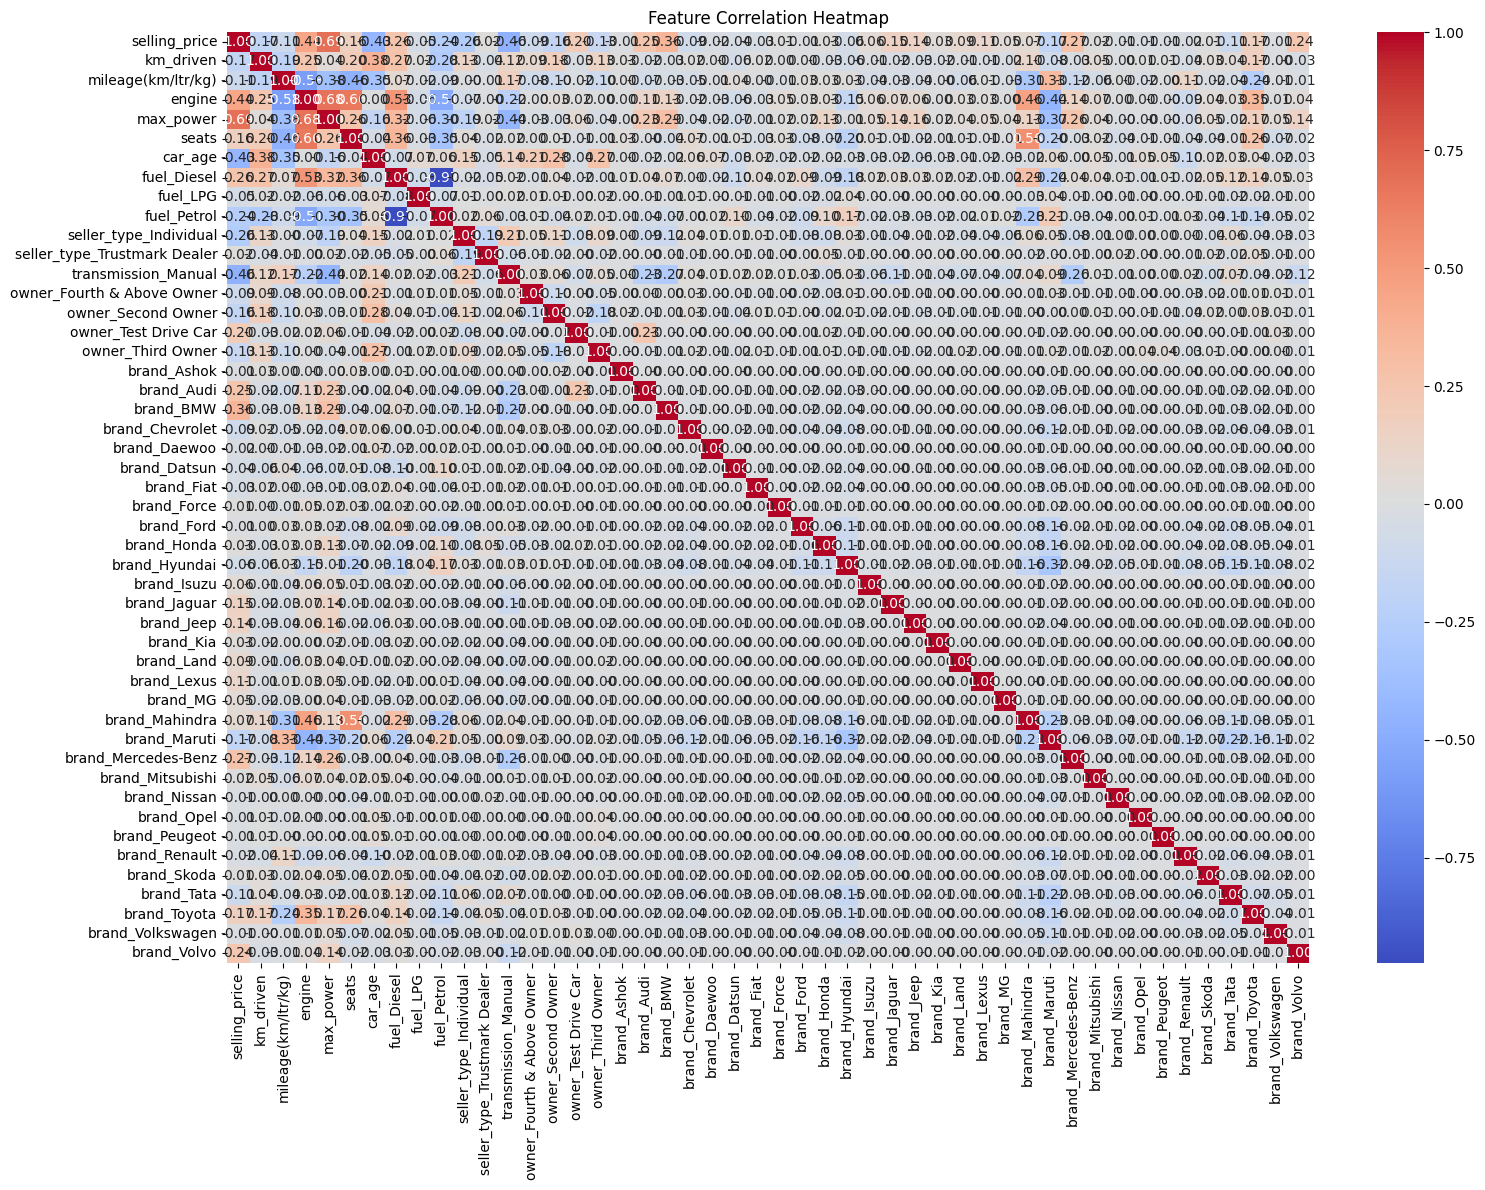

In [103]:
#Display the correlation heatmap
plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()

plt.show()

### 5.5. Inspect correlations with the target

In [104]:
correlation_matrix["selling_price"].sort_values(
    ascending=False
)

selling_price                   1.000000
max_power                       0.688838
engine                          0.444760
brand_BMW                       0.358378
brand_Mercedes-Benz             0.273134
fuel_Diesel                     0.256397
brand_Audi                      0.253625
brand_Volvo                     0.244222
owner_Test Drive Car            0.200995
brand_Toyota                    0.166958
seats                           0.163942
brand_Jaguar                    0.145973
brand_Jeep                      0.138152
brand_Lexus                     0.107115
brand_Land                      0.088093
brand_Mahindra                  0.065215
brand_Isuzu                     0.057133
brand_MG                        0.050710
brand_Kia                       0.034261
brand_Honda                     0.025436
seller_type_Trustmark Dealer    0.024175
brand_Mitsubishi                0.018522
brand_Force                     0.014985
brand_Skoda                     0.014420
brand_Ashok     

### Observation

Maximum power shows the strongest positive correlation with selling price (r = 0.689), while manual transmission (r = −0.463) and car age (r = −0.433) show the strongest negative correlations. Engine size also exhibits a moderate positive association (r = 0.445). These results indicate that vehicle performance characteristics, age, and transmission type are among the variables most strongly linearly associated with selling price in this dataset.


## Step 6: Train/Test Split
### Objective

We need to separate the dataset into:

+ Features (X): variables used to predict the price.
+ Target (y): the value we want to predict, selling_price.

### 6.1. Define X and Y

In [107]:
X = df_model.drop(
    columns=["selling_price"]
)

y = df_model["selling_price"]

### 6.2. Split the data

In [108]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#Verify the split
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (5540, 47)
Testing features: (1386, 47)
Training target: (5540,)
Testing target: (1386,)


## Step 7: Train Two Regression Models

### 7.1. Model 1: Linear Regression

In [109]:
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

LinearRegression()

In [110]:
#Generate Predictions
y_pred_linear = linear_model.predict(
    X_test
)

### 7.2. Model 2: Random Forest Regressor

In [111]:
random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train,
    y_train
)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [112]:
#Generate Predictions

y_pred_rf = random_forest_model.predict(
    X_test
)

## Step 8: Evaluate the Models

We will use the three metrics:

+ MAE
+ RMSE
+ R²

In [114]:
#Create a function to avoid repeating code:
def evaluate_model(
    model_name,
    y_true,
    y_pred
):
    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    }

In [116]:
# Evaluate both models
linear_results = evaluate_model(
    "Linear Regression",
    y_test,
    y_pred_linear
)

rf_results = evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf
)

In [117]:
#Create a comparision table
results = pd.DataFrame([
    linear_results,
    rf_results
])

results

,Model,MAE,RMSE,R²
0,Linear Regression,133098.533351,262236.186555,0.686452
1,Random Forest,72638.143524,128585.486844,0.924612


### Model Evaluation

The Random Forest Regressor outperformed Linear Regression, achieving the lowest MAE (72,638.14) and RMSE (128,585.49) and the highest R² score (0.925), explaining 92.5% of the variance in selling prices and demonstrating superior performance in capturing nonlinear relationships.

## Step 9: Feature Importance Chart for the Best-Performing Model

### 9.1. Extract feature importance
The Random Forest model calculates an importance value for every feature:

In [119]:
best_model = random_forest_model

In [120]:
feature_importance = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
)

### 9.2. Sort the features

In [122]:
feature_importance = feature_importance.sort_values(
    ascending=False
)

#Display the important values
feature_importance

max_power                       5.987382e-01
car_age                         2.302940e-01
km_driven                       4.484264e-02
mileage(km/ltr/kg)              4.118792e-02
engine                          2.293243e-02
seats                           9.067434e-03
brand_Mercedes-Benz             6.073466e-03
transmission_Manual             5.974010e-03
brand_Toyota                    5.399121e-03
brand_BMW                       4.203663e-03
brand_Tata                      4.130396e-03
brand_Land                      3.851452e-03
fuel_Petrol                     2.743934e-03
fuel_Diesel                     2.505299e-03
seller_type_Individual          2.360934e-03
owner_Second Owner              2.045657e-03
brand_Skoda                     1.569091e-03
owner_Test Drive Car            1.456435e-03
brand_Chevrolet                 1.221274e-03
brand_Volkswagen                1.114466e-03
brand_Ford                      1.073504e-03
brand_Volvo                     1.009350e-03
brand_Audi

### 9.3. Create the feature importance chart

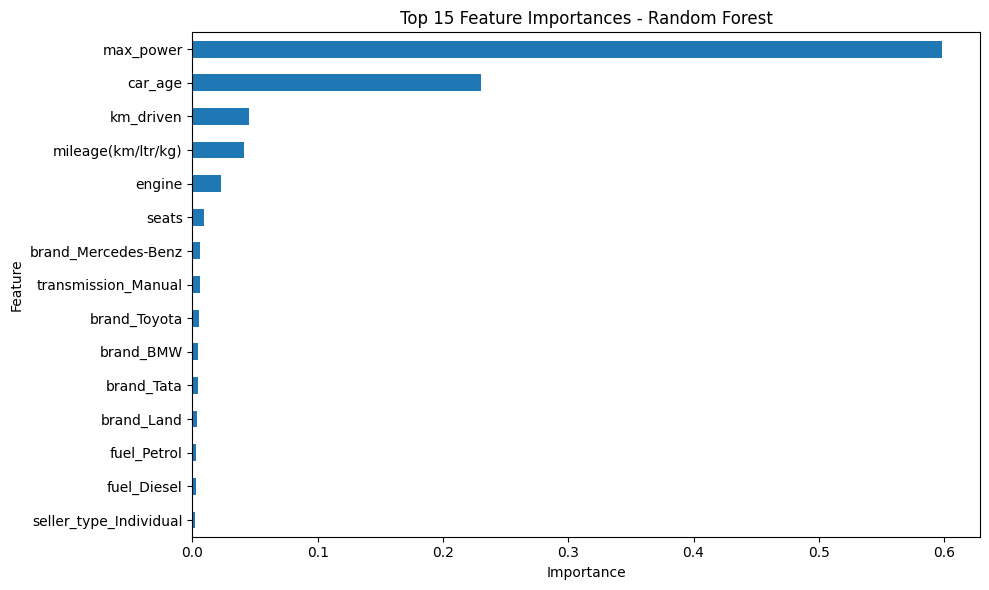

In [124]:
#Select the 15 most important features
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

top_features.sort_values().plot(
    kind="barh"
)

plt.title(
    "Top 15 Feature Importances - Random Forest"
)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()

plt.show()

Observation

Maximum power (59.9%) and car age (23.0%) are the dominant features in the Random Forest model, followed by kilometers driven (4.5%) and mileage (4.1%). These results indicate that vehicle performance and age are the primary predictors of selling price.